# Intron Analysis v2

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(viridis)
library("ComplexHeatmap")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.6     ✔ dplyr   1.0.8
✔ tidyr   1.2.0     ✔ stringr 1.4.0
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

Loading required package: viridisLite

Loading required package: grid

ComplexHeatmap version 2.6.2
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
intron_data <- read.csv("input/rna_velocity_results_20220310/all_stats.csv") %>% rename(sample=subject)

- **total_reads** total number of umi
- **target_region_reads** reads that cover or near to the intron position
- **spliced_reads** splicing reads
- **intronic reads** reads in intron (at least 5 nt)
- **unsure_reads** reads in the region but did not match the criteria

- **Commentaries**
1. If there is a skip in the alignment, it is considered that the read did a split.
2. If the splice does not match completely with the complete intron, it will have a comment, if it is shorter, larger or it starts in another place, this is indicated between parenthesis with 2 numbers, the first number is what was obtained from the reads and the second number is what should be. (threshold more than 3 nt. of difference)
3. It has to be a cover of the intron at least 5 nt. to call that read intronic. it means that could be intronic and spiced reads if the spliced reads cover partially the intron.
4. If a read has no splice and coverage less than 5 nt. in the intron is defined as unsure.
5. Now also is included the reads that cover partially the intron region (in the analysis before was only considered the one that covers all the intron), which means that the coverage should be better in general.

In [4]:
head(intron_data)

,sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,K1B_S10000,LC,TTAGGCAGTCGAACAG,AAACCCGGCA,35,28,28,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
2,K1B_S10000,LC,TTAGGCAGTCGAACAG,AAGACTATGA,63,53,53,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
3,K1B_S10000,LC,TTAGGCAGTCGAACAG,ACGTATATGG,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
4,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGAAAATCGC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
5,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGGGTACGC,69,57,57,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
6,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGTGTGCCT,21,20,0,19,1,100,7,,16;16;16;16;16;16;16;16;6;6;6;6;7;7;7;7;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5


In [5]:
# unique cell intron_data
length(unique(intron_data$cell))

[1] 76

## Join scSHM df with intron data

In [6]:
# #events all filter, df to obtain the cell with scSHM events
df_summary <- read.csv("output/df_summary.csv")

#Select cell from df_summary (71)
cell_shm <- df_summary %>% pull(cell) %>% unique()

In [7]:
# events until filter 4 and filter for unique cell from df_summary (scSHM (+))
df <- read.csv("output/df_f4.csv") %>% mutate(sample=gsub(".{3}$", "", subject)) %>% filter(cell %in% cell_shm) 
head(df)

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000


In [8]:
# unique cell df with scSHM events
length(unique(df$cell))

[1] 71

In [9]:
# Join df with cell scSHM with intron data
df_intron <- df %>% filter(cell %in% cell_shm) %>% left_join(intron_data, c("cell","umi","sample")) #%>% filter(is.na(mediandepth))
head(df_intron)

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,⋯,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,⋯,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,⋯,LC,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,⋯,LC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,⋯,LC,90,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,⋯,LC,96,81,81,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,⋯,LC,92,70,70,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,⋯,LC,85,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


## Define a categorical variable about the splice status

In [10]:
# Define categorical variable about the splice status
options(repr.matrix.max.cols = 150)
df_intron_ov <- df_intron %>% mutate(intron_status=case_when(target_region_reads == 0 ~ "no_reads_intron_region",
                                                            is.na(chain) ~ "no_data",
                                                            intronic_reads > spliced_reads & intron_coverage_percentage > 80 ~ "unspliced",
                                                            spliced_reads > intronic_reads ~ "spliced",
                                                            grepl("short",intron_comments) ~ "spliced",
                                                            intronic_reads > spliced_reads & spliced_reads < 4  ~ "undetermined", #| spliced_reads - intronic_reads <= 4
                                                            TRUE ~ "na")) %>%
               mutate(match=if_else(nucl != cons_nucl, "New","Old"))

head(df_intron_ov)  

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


## TEST

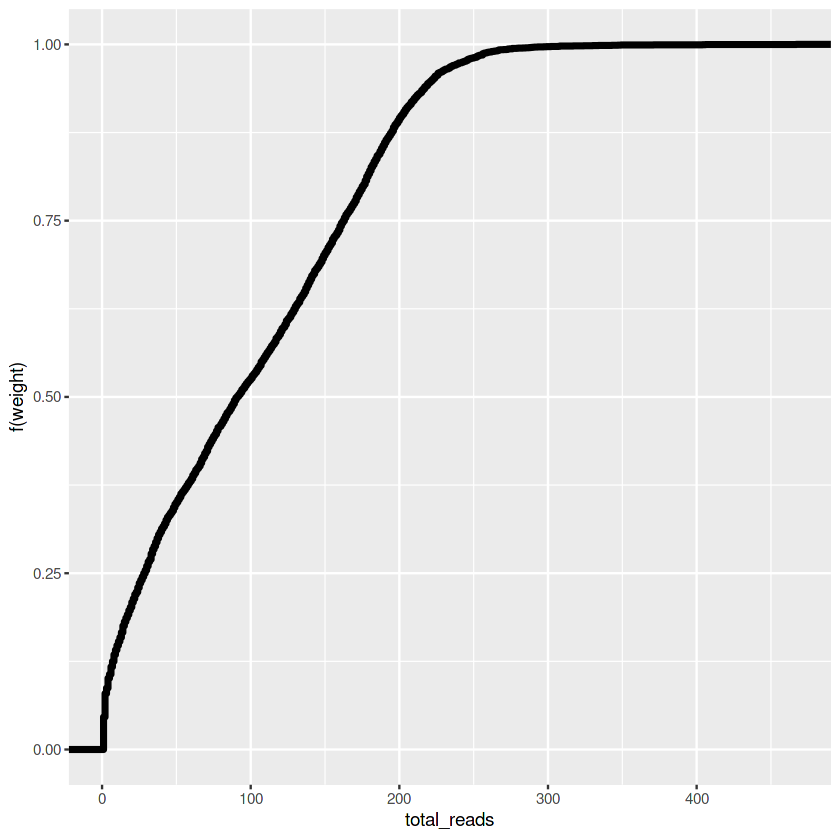

In [11]:
a <- ggplot(intron_data, aes(x = total_reads)) #total_reads

# Another option for geom = "point"
a + stat_ecdf( 
              geom = "step", size = 1.5) +
  scale_color_manual(values = c("#00AFBB"))+
  labs(y = "f(weight)")

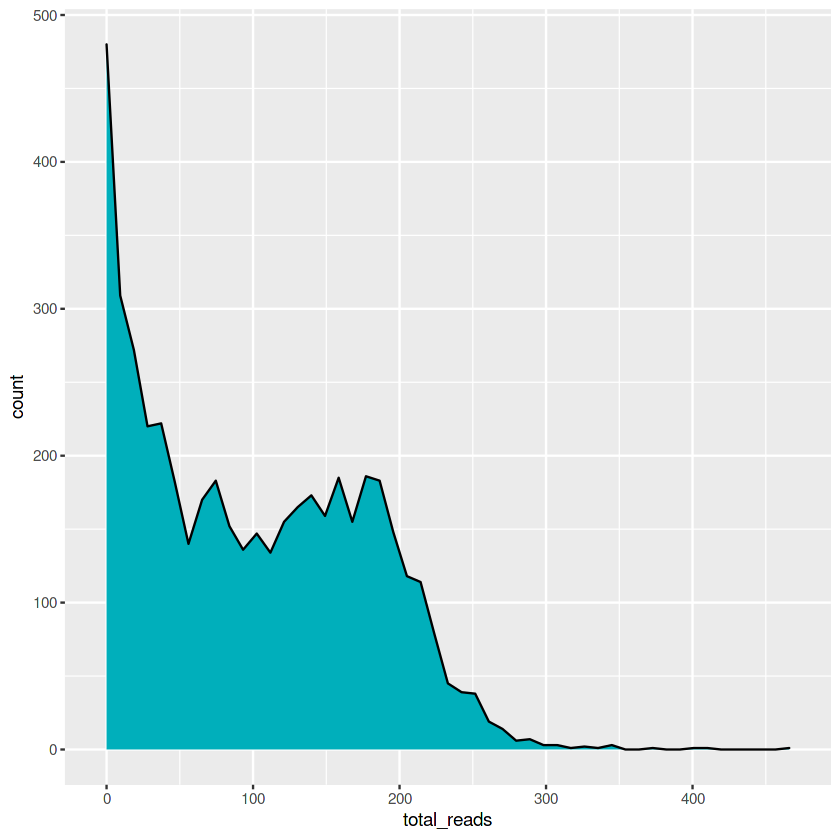

In [12]:
# Basic area plots, which can be filled by color
a + geom_area( stat = "bin", bins = 51,
               color = "black", fill = "#00AFBB")

`geom_smooth()` using formula 'y ~ x'



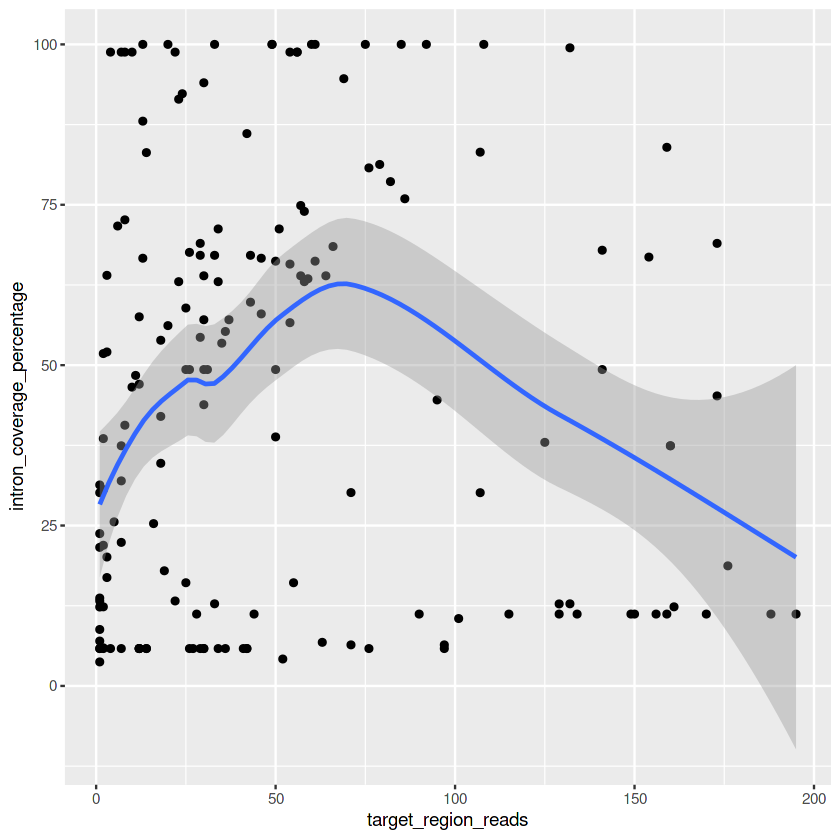

In [13]:
b <- ggplot(intron_data %>% filter(!intron_coverage_percentage == 0), aes(x = target_region_reads, y = intron_coverage_percentage))
# Scatter plot with regression line
     
# Add a loess smoothed fit curve
b + geom_point()+
  geom_smooth(method = "loess") 

`geom_smooth()` using formula 'y ~ x'



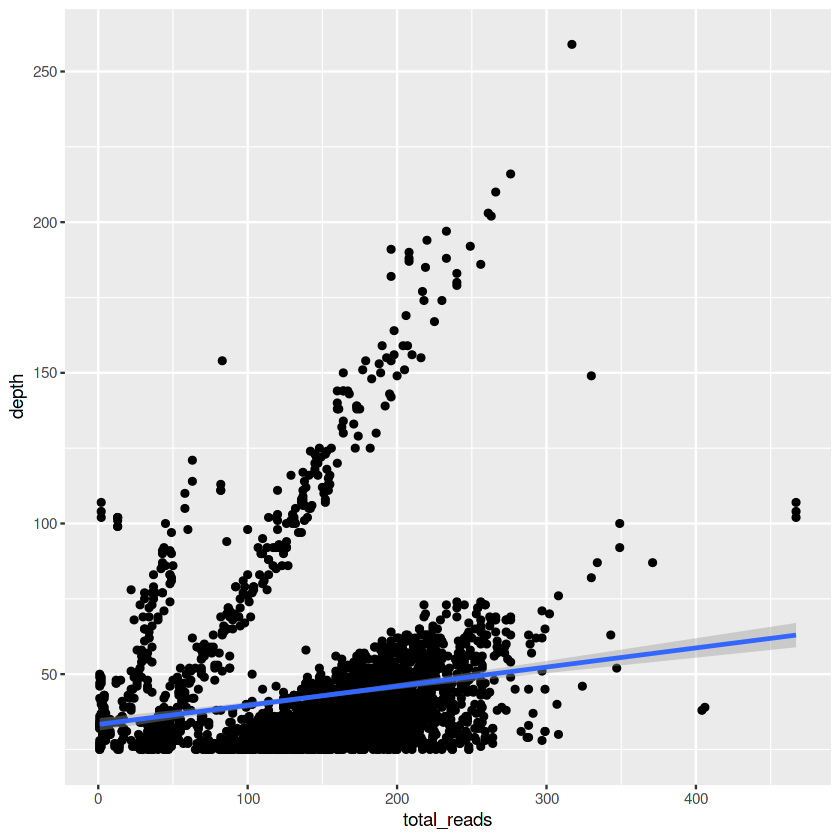

In [14]:
b <- ggplot(df_intron_ov , aes(x = total_reads, y =depth))
# Scatter plot with regression line
     
# Add a loess smoothed fit curve
b + geom_point()+
  geom_smooth(method = "lm")  #"loess"

## PLOTING: Splice status by cell

In [16]:
intron_perc <- df_intron_ov %>%  group_by(cell) %>% count(intron_status,match) %>%#summarise(median_intron=n(mediandepth)) 
               group_by(cell) %>%
               mutate(Perc_umi =n * 100 / sum(n)) 

In [17]:
#define gene order for plotting
cell_order <- intron_perc %>% group_by(cell,intron_status) %>% arrange(-Perc_umi) %>% pull(cell) %>% unique()

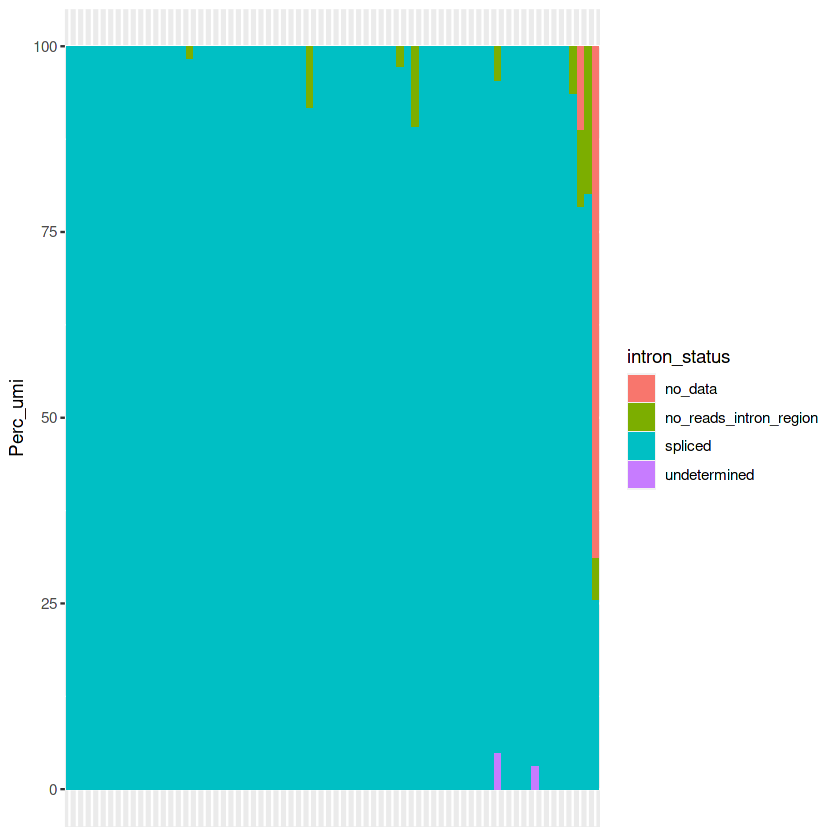

In [18]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_umi, fill=intron_status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

## PLOTING: Splice status only in cells with unspliced umis

In [19]:
cell_intron <- intron_perc %>% filter(intron_status == "unspliced") %>% pull(cell) %>% unique()
cell_intron

character(0)

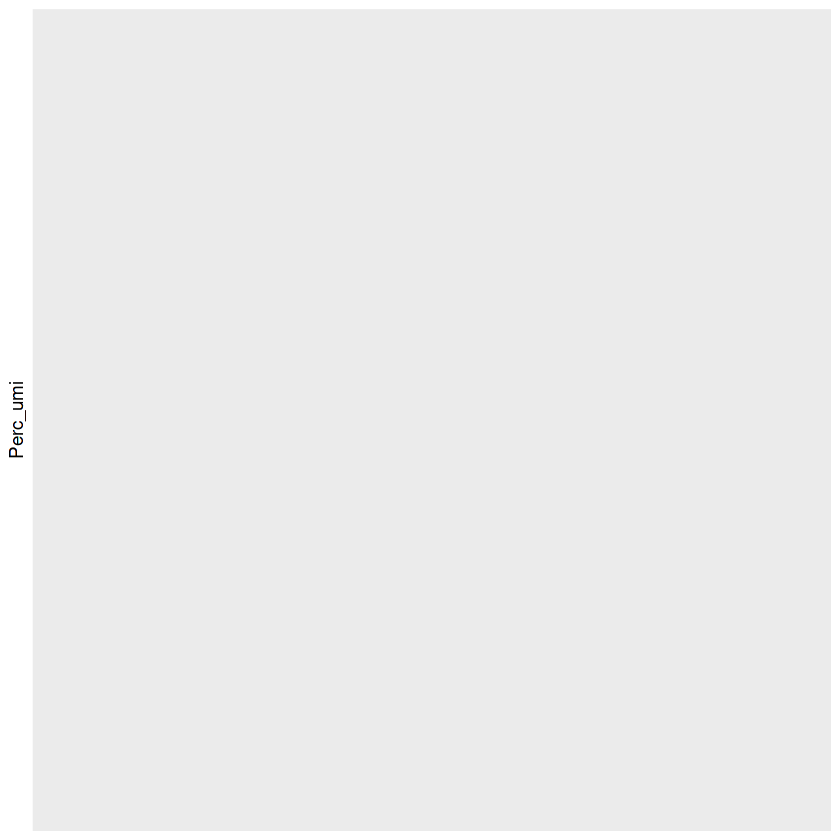

In [20]:
# Stacked barplot with multiple groups
intron_plot <- intron_perc  %>% filter(cell %in% cell_intron) %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=cell, y=Perc_umi, fill=intron_status)) +
  geom_bar(stat="identity") +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank())

intron_plot

fig_save(intron_plot, filename ="figs/FL/intron_cell_filter", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

## Correlation between the spliced status and if the events is the same or not to primordial (only for cell with unspliced umis)

In [21]:
# # Stacked barplot with multiple groups
# intron_plot <- intron_perc  %>% filter(cell %in% cell_intron, !intron_status  %in% c("unknown", "no_reads_intron_region")) %>% mutate(cell = factor(cell, levels = cell_order)) %>%
#  ggplot(aes(x=intron_status, y=n, fill=match)) +
#   geom_bar(stat="identity") +
#   theme(axis.title.x=element_blank(),
#         strip.text.x = element_text(size = 4),
#         axis.text.x=element_text(angle = 90),
#         axis.ticks.x=element_blank()) +
#         ylab("UMI amount") +
#         facet_grid(~cell)

# intron_plot

# fig_save(intron_plot, filename ="figs/FL/intron_cell_filter_by cell", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

### Splice status by cell (grouped)

In [22]:
intron_perc_by_status <- df_intron_ov %>%  filter(!intron_status %in% c("no_reads_intron_region","no_data")) %>%group_by(cell) %>% count(intron_status) %>%#summarise(median_intron=n(mediandepth)) 
               group_by(cell) %>%
               mutate(Perc_umi =n * 100 / sum(n)) 

head(intron_perc_by_status)

cell,intron_status,n,Perc_umi
<chr>,<chr>,<int>,<dbl>
AAATGCCTCTGAAAGA,spliced,97,100
AACACGTAGCCACCTG,spliced,10,100
AACTCAGCAAATCCGT,spliced,41,100
AACTCAGCATTCGACA,spliced,19,95
AACTCAGCATTCGACA,undetermined,1,5
AACTCCCAGATATACG,spliced,11,100


In [23]:
#number cell without introns
intron_perc_by_status %>% filter(intron_status == "spliced" & Perc_umi == 100 ) %>% pull(cell) %>% unique() %>% length()

[1] 69

## Heatmap

In [24]:
# mu_shm_perc_matrix <- intron_perc_by_status  %>% 
# select(cell,intron_status,n) %>% pivot_wider(cell, names_from=intron_status, values_from=n) %>% column_to_rownames(var="cell") %>%
# replace(is.na(.), 0)

# head(mu_shm_perc_matrix)

In [25]:
intron_match <- df_intron_ov %>% filter(!intron_status  %in% c("undetermined", "no_reads_intron_region", "no_data")) %>% group_by(cell, intron_status) %>% count(match) %>%
               group_by(cell,intron_status) %>%
               mutate(Perc_match =n * 100 / sum(n)) 

head(intron_match)

cell,intron_status,match,n,Perc_match
<chr>,<chr>,<chr>,<int>,<dbl>
AAATGCCTCTGAAAGA,spliced,New,36,37.11340
AAATGCCTCTGAAAGA,spliced,Old,61,62.88660
AACACGTAGCCACCTG,spliced,New,5,50.00000
AACACGTAGCCACCTG,spliced,Old,5,50.00000
AACTCAGCAAATCCGT,spliced,New,18,43.90244
AACTCAGCAAATCCGT,spliced,Old,23,56.09756


In [26]:
mu_shm_perc_matrix <- intron_match  %>% 
dplyr::select(cell,match,Perc_match) %>% pivot_wider(cell, names_from=match, values_from=Perc_match) %>% column_to_rownames(var="cell") %>%
replace(is.na(.), 0) %>% t()

head(mu_shm_perc_matrix)

Adding missing grouping variables: `intron_status`


,AAATGCCTCTGAAAGA,AACACGTAGCCACCTG,AACTCAGCAAATCCGT,AACTCAGCATTCGACA,AACTCCCAGATATACG,AACTCCCAGCGATATA,AACTCTTGTGCAACTT,ACACCCTCACACCGCA,ACGCAGCAGCAGGCTA,ACGCCAGAGGCATTGG,ACTGTCCCAGCTGGCT,AGCGTATTCTGAAAGA,AGGTCATCAGTTCCCT,AGTGAGGGTCGATTGT,AGTGTCACAGCTGGCT,ATAACGCCAAGCCGCT,ATCATGGGTGGTCTCG,ATGAGGGGTGTATGGG,ATTGGACCACACCGCA,CAACCAAAGTTACGGG,CAACCTCGTCTGATTG,CAAGAAAAGTCCGGTC,CAAGAAAGTCTCCACT,CAAGTTGCAGCTGTGC,CACACCTGTTGTGGAG,CACAGTACAGGATCGA,CACATAGTCATACGGT,CACCACTAGCCTCGTG,CACCAGGGTTCGCTAA,CAGCGACCACAGCGTC,CATCAGAAGCGAAGGG,CCAATCCTCGGAAATA,CCACTACGTTAAGTAG,CCACTACTCAGTTTGG,CCATGTCCACCAGGCT,CCTACCATCATGCATG,CCTTCCCTCTCGCATC,CGACCTTGTTCCAACA,CGATCGGAGCTACCTA,CGCGGTATCAGGCAAG,CGGACTGAGCTGAAAT,CGGCTAGTCCTTGACC,GAGCAGATCTAACTGG,GAGGTGAAGTGGACGT,GATCAGTAGTAACCCT,GATCGTATCCCATTTA,GATCTAGTCGCCGTGA,GATGCTATCTTCCTTC,GCACATATCGCTTAGA,GCACATATCTCTAGGA,GGAATAAGTCTCTCGT,GGCCGATAGATTACCC,GGCTGGTTCCCACTTG,GTAACTGCAATCCAAC,GTAGGCCTCTGAGTGT,GTCACAACAACGATCT,GTGTTAGAGGGAACGG,GTTCTCGCAAGCTGAG,TAAACCGAGGATGGTC,TAAGAGATCAAACCGT,TACCTATAGCGATCCC,TACCTATAGGTTCCTA,TCTTTCCGTCTAGTCA,TGCTGCTGTACAGTGG,TGGCTGGGTAGTAGTA,TGTGGTAAGGCGACAT,TGTTCCGTCGGCGCAT,TTAGGCAGTCGAACAG,TTATGCTCACACCGAC,TTATGCTCATCCTTGC,TTTCCTCCACTTAAGC
New,37.1134,50,43.90244,42.10526,45.45455,61.53846,39.02439,48.71795,45,49.33333,38.09524,36,46.66667,41.37931,42.46575,46.55172,34.32836,26.59574,46.15385,20,50,31.03448,36,42.85714,21.95122,38.46154,33.66834,45.45455,38.35616,52.38095,44.77612,41.17647,45.45455,39.02439,44.44444,47.61905,41.66667,42.10526,31.25,42.85714,38.55422,51.72414,37.16814,52.77778,47.05882,43.47826,36.36364,50,31.91489,42.10526,38.09524,40.90909,48.27586,46.875,45.45455,34.28571,47.72727,40.47619,40.81633,40,32.25806,50,39.53488,43.47826,61.53846,41.66667,42.85714,61.53846,35.71429,41.52047,45.09804
Old,62.8866,50,56.09756,57.89474,54.54545,38.46154,60.97561,51.28205,55,50.66667,61.90476,64,53.33333,58.62069,57.53425,53.44828,65.67164,73.40426,53.84615,80,50,68.96552,64,57.14286,78.04878,61.53846,66.33166,54.54545,61.64384,47.61905,55.22388,58.82353,54.54545,60.97561,55.55556,52.38095,58.33333,57.89474,68.75,57.14286,61.44578,48.27586,62.83186,47.22222,52.94118,56.52174,63.63636,50,68.08511,57.89474,61.90476,59.09091,51.72414,53.125,54.54545,65.71429,52.27273,59.52381,59.18367,60,67.74194,50,60.46512,56.52174,38.46154,58.33333,57.14286,38.46154,64.28571,58.47953,54.90196


In [27]:
col_fun = circlize::colorRamp2(seq(0, 100, by=10), rev(terrain.colors(11)))

    
png(file="figs/FL/heatmap_match.png",width=25,height=7,units="cm",res=300)
Heatmap(mu_shm_perc_matrix, 
        cluster_rows= FALSE,cluster_columns= FALSE, #column_km= 3,
        row_dend_reorder= TRUE,
        name = "% UMIs",#title of legend 
        column_title = "gene_status", column_title_side="bottom",row_title = "Cells", #split = mu_shm_perc_matrix$L_unspliced,
        row_names_gp = gpar(fontsize = 9), # Text size for row names
        column_names_gp = gpar(fontsize = 4),
        col= col_fun #(rainbow(10)),
#         rect_gp=gpar(col="white", lwd=2)
       )
dev.off()

png 
  2

## Bubble plot (alternative to heatmap)

In [28]:
head(intron_match)

cell,intron_status,match,n,Perc_match
<chr>,<chr>,<chr>,<int>,<dbl>
AAATGCCTCTGAAAGA,spliced,New,36,37.11340
AAATGCCTCTGAAAGA,spliced,Old,61,62.88660
AACACGTAGCCACCTG,spliced,New,5,50.00000
AACACGTAGCCACCTG,spliced,Old,5,50.00000
AACTCAGCAAATCCGT,spliced,New,18,43.90244
AACTCAGCAAATCCGT,spliced,Old,23,56.09756


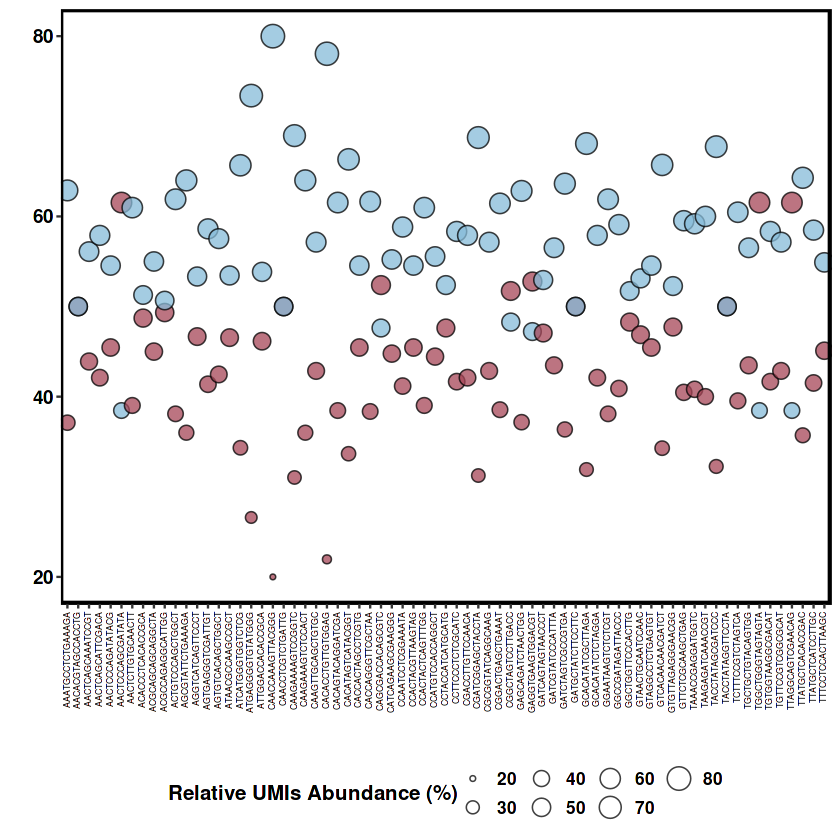

In [29]:
colours = c( "#A54657",  "#86BBD8","#582630", "#F7EE7F", "#4DAA57","#F1A66A","#F26157", "#F9ECCC", "#679289", "#33658A",
"#F6AE2D")

xx = ggplot(intron_match, aes(x = cell, y = Perc_match)) + 
  geom_point(aes(size = Perc_match, fill = match), alpha = 0.75, shape = 21) + 
#  scale_size_continuous(limits = c(0.000001, 100), range = c(1,10), breaks = c(25,50,75,100)) + 
  labs( x= "", y = "", size = "Relative UMIs Abundance (%)", fill = "")  + 
  theme(legend.key=element_blank(), 
  axis.text.x = element_text(colour = "black", size = 5, angle = 90, vjust = 0.3, hjust = 1), 
  axis.text.y = element_text(colour = "black", face = "bold", size = 11), 
  legend.text = element_text(size = 10, face ="bold", colour ="black"), 
  legend.title = element_text(size = 12, face = "bold"), 
  panel.background = element_blank(), panel.border = element_rect(colour = "black", fill = NA, size = 1.2), 
  legend.position = "bottom") +  
   scale_fill_manual(values = colours, guide = FALSE) #+ 
#   coord_fixed(ratio = 0.5)
#   facet_wrap(~cell, nrow=5)
#    scale_y_discrete(limits = rev(levels(intron_match$match))) 

xx

fig_save(xx, filename ="figs/FL/bubble_plot_match", formats = c("pdf", "png"), width = 25, height =15, units = "cm", dpi = 320)

# TEST

ERROR while rich displaying an object: Error in `combine_vars()`:
! Faceting variables must have at least one value

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
7. repr::mime2repr[[mime]](obj)
8. repr_text

ERROR: [1m[33mError[39m in [1m[1m`combine_vars()`:[22m
[33m![39m Faceting variables must have at least one value


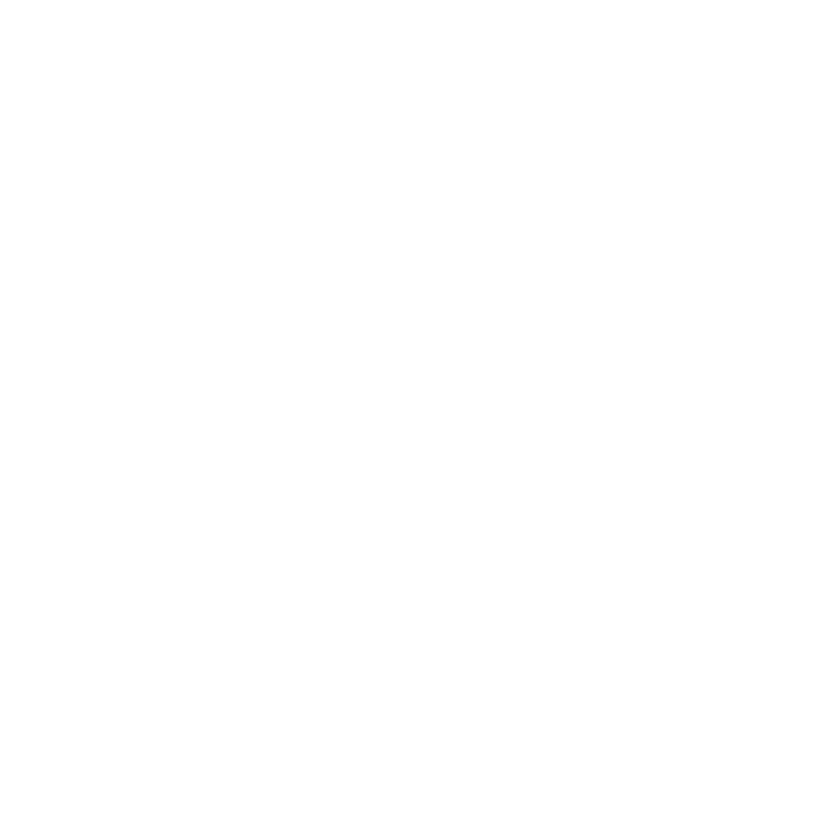

In [30]:

p <- ggplot(intron_match %>% select(-n) %>% filter(cell %in% cell_intron), aes(intron_status,Perc_match,fill=match)) + geom_bar(stat="identity")
p <- p  + coord_polar(theta="y") + facet_wrap(~cell,,ncol=2) + theme_bw() +
     theme(strip.text.x = element_text(size=5.5), text = element_text(size = 7))
p

fig_save(p, filename ="figs/FL/intron_cell_filter_by cell_pie", formats = c("pdf", "png"), width = 10, height =15, units = "cm", dpi = 320)

## Check bam aligments

### Read partially cover intron

In [85]:
df_intron_ov %>% filter(intron_status == "undetermined") 

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCATTCGACA,TCCCGGCCCC,167,T,T,CC.TC,125,TRUE,V,61,61,A,CC.TC,FR1,K1B_S144-LC,K1B_S144,LC,148,97,0,93,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;2;92;93;93;93;93;93;93,undetermined,Old
CCTACCATCATGCATG,ATTATCAACC,197,G,A,AA.TG,36,TRUE,V,92,92,A,AA.TG,CDR1,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,246,G,C,CT.AT,25,TRUE,V,141,141,G,CT.AT,FR2,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,270,G,A,CA.AG,26,TRUE,V,165,165,A,CA.AG,FR3,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,271,C,A,AA.GT,26,TRUE,V,166,166,A,AA.GT,FR3,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New


In [31]:
df_intron_ov %>% filter(subject == "K1B_S144-LC", cell == "CCTACCATCATGCATG", umi == "ATTATCAACC") #, umi == "AAGGGGTGAT"

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
CCTACCATCATGCATG,ATTATCAACC,197,G,A,AA.TG,36,TRUE,V,92,92,A,AA.TG,CDR1,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,246,G,C,CT.AT,25,TRUE,V,141,141,G,CT.AT,FR2,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,270,G,A,CA.AG,26,TRUE,V,165,165,A,CA.AG,FR3,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New
CCTACCATCATGCATG,ATTATCAACC,271,C,A,AA.GT,26,TRUE,V,166,166,A,AA.GT,FR3,K1B_S144-LC,K1B_S144,LC,108,71,1,66,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;3;3;66;66;66;66;66;66,undetermined,New


In [86]:
df_intron_ov %>% filter(subject == "K1B_S144-LC", cell == "AACTCAGCATTCGACA", umi == "TCCCGGCCCC") #, umi == "AAGGGGTGAT"

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCATTCGACA,TCCCGGCCCC,167,T,T,CC.TC,125,TRUE,V,61,61,A,CC.TC,FR1,K1B_S144-LC,K1B_S144,LC,148,97,0,93,4,6.4,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;2;92;93;93;93;93;93;93,undetermined,Old


### Read split and partially cover intron

In [87]:
# Define categorical variable about the splice status
options(repr.matrix.max.cols = 150)
df_aberrant_splice <- df_intron %>% mutate(intron_status=case_when(target_region_reads == 0 ~ "no_reads_intron_region",
                                                            is.na(chain) ~ "no_data",
                                                            intronic_reads > spliced_reads & intron_coverage_percentage > 80 ~ "unspliced",
                                                            spliced_reads > intronic_reads ~ "spliced",
                                                            grepl("short",intron_comments) ~ "spliced&ab_intron",
                                                            intronic_reads > spliced_reads & spliced_reads < 4  ~ "undetermined", #| spliced_reads - intronic_reads <= 4
                                                            TRUE ~ "na")) %>%
               mutate(match=if_else(nucl != cons_nucl, "New","Old"))

head(df_aberrant_splice)  

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
1,TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
2,TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
3,TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
4,TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
5,TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
6,TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [88]:
df_aberrant_splice %>% filter(intron_status ==  "spliced&ab_intron")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AGTGAGGGTCGATTGT,AAGGGGTGAT,149,G,G,GA.TC,49,TRUE,V,55,55,G,GA.TC,FR1,K1B_S144-LC,K1B_S144,LC,210,170,165,165,1,11.200000,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;162;162;163;163;163;163;163;163;165;165;165;165;164;163,spliced&ab_intron,Old
GATGCTATCTTCCTTC,GCGAGGCCAC,254,G,G,AT.CT,25,TRUE,V,148,148,G,AT.CT,CDR2,K1B_S144-LC,K1B_S144,LC,194,159,153,157,0,11.200000,0,short(112--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;152;152;152;153;153;153;155;155;155;154;154;153;153;153,spliced&ab_intron,Old
CAACCTCGTCTGATTG,GGGGGTTTCA,539,C,C,GG.AA,25,TRUE,V,124,124,A,GG.AA,FR2,K1B_S144-LC,K1B_S144,LC,162,132,126,128,2,12.800000,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;124;125;125;125;125;125;125;126;128;128;128;128;128;128,spliced&ab_intron,Old
AACTCAGCAAATCCGT,ACACCATTGT,133,G,G,GT.AA,103,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,130,97,96,96,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;96;96;96;96;96;96,spliced&ab_intron,Old
AACTCAGCAAATCCGT,GCTACTAGGG,133,G,G,GT.AA,81,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,97,76,75,75,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;75;75;75;75;75;75,spliced&ab_intron,Old
AACTCAGCAAATCCGT,GTCCGACAGT,133,G,G,GT.AA,36,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,49,34,34,34,0,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;34;34;34;34;34;34,spliced&ab_intron,Old
AACTCAGCAAATCCGT,TATAAGCTAA,133,G,G,GT.AA,34,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,127,36,35,35,0,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;35;35;35;35;35;35,spliced&ab_intron,Old
AACTCAGCAAATCCGT,ACACCATTGT,145,A,A,TG.TG,100,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,130,97,96,96,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;96;96;96;96;96;96,spliced&ab_intron,Old
AACTCAGCAAATCCGT,GCTACTAGGG,145,A,A,TG.TG,26,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,97,76,75,75,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;75;

In [95]:
df_aberrant_splice %>% filter(umi == "ACCGGTTATA")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
GTCACAACAACGATCT,ACCGGTTATA,121,C,G,TC.TC,38,TRUE,V,27,27,C,TC.TC,FR1,K1B_S144-LC,K1B_S144,LC,134,115,113,112,1,11.2,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;112;112;112;112;112;112;112;111;111;111;110;110;110;110,spliced,New
GTCACAACAACGATCT,ACCGGTTATA,207,A,C,GC.GA,29,TRUE,V,113,113,A,GC.GA,FR2,K1B_S144-LC,K1B_S144,LC,134,115,113,112,1,11.2,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;112;112;112;112;112;112;112;111;111;111;110;110;110;110,spliced,New


### Reads split and partially cover beginning intron

In [96]:
df_aberrant_splice %>% filter(umi == "ATCATTCTCT") AAACCACTAG

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
GTTCTCGCAAGCTGAG,ATCATTCTCT,130,G,G,GA.TG,32,TRUE,V,27,31,C,GA.TG,FR1,K2B_S12500-HC,K2B_S12500,HC,130,95,91,4,0,44.57831,0,,4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;2;2;2;2;2;2;2;2;2;2;2;2;2;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
GTTCTCGCAAGCTGAG,ATCATTCTCT,141,T,T,CC.TC,28,TRUE,V,38,42,T,CC.TC,FR1,K2B_S12500-HC,K2B_S12500,HC,130,95,91,4,0,44.57831,0,,4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;2;2;2;2;2;2;2;2;2;2;2;2;2;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [97]:
df_aberrant_splice %>% filter(umi == "AAACCACTAG") 

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
ATAACGCCAAGCCGCT,AAACCACTAG,282,A,A,GA.AT,46,TRUE,V,3,3,A,GA.AT,FR1,K1B_S8934-LC,K1B_S8934,LC,217,176,172,4,0,18.71658,0,,4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;2;2;2;2;2;2;2;2;2;2;2;2;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
ATAACGCCAAGCCGCT,AAACCACTAG,294,G,A,AC.CA,49,TRUE,V,15,15,G,AC.CA,FR1,K1B_S8934-LC,K1B_S8934,LC,217,176,172,4,0,18.71658,0,,4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;2;2;2;2;2;2;2;2;2;2;2;2;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New


In [93]:
df_aberrant_splice %>% filter(intron_coverage_percentage >= 6.4)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCATTCGACA,TCCCGGCCCC,167,T,T,CC.TC,125,TRUE,V,61,61,A,CC.TC,FR1,K1B_S144-LC,K1B_S144,LC,148,97,0,93,4,6.40000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;2;92;93;93;93;93;93;93,undetermined,Old
AGTGAGGGTCGATTGT,AAGGGGTGAT,149,G,G,GA.TC,49,TRUE,V,55,55,G,GA.TC,FR1,K1B_S144-LC,K1B_S144,LC,210,170,165,165,1,11.20000,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;162;162;163;163;163;163;163;163;165;165;165;165;164;163,spliced&ab_intron,Old
GATGCTATCTTCCTTC,GCGAGGCCAC,254,G,G,AT.CT,25,TRUE,V,148,148,G,AT.CT,CDR2,K1B_S144-LC,K1B_S144,LC,194,159,153,157,0,11.20000,0,short(112--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;152;152;152;153;153;153;155;155;155;154;154;153;153;153,spliced&ab_intron,Old
CACACCTGTTGTGGAG,GTAGGATTGT,179,G,C,GG.CA,55,TRUE,V,73,73,G,GG.CA,FR1,K1B_S144-LC,K1B_S144,LC,245,195,195,1,0,11.20000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;1;1;1;1;1;1;1;1;1;1;1;1,spliced,New
CACACCTGTTGTGGAG,TGGGTTCCCC,179,G,C,GG.CA,34,TRUE,V,73,73,G,GG.CA,FR1,K1B_S144-LC,K1B_S144,LC,167,134,134,1,0,11.20000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;1;1;1;1;1;1;1;1;1;1;1;1,spliced,New
CAACCTCGTCTGATTG,GGGGGTTTCA,539,C,C,GG.AA,25,TRUE,V,124,124,A,GG.AA,FR2,K1B_S144-LC,K1B_S144,LC,162,132,126,128,2,12.80000,0,short(111--125),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;124;125;125;125;125;125;125;126;128;128;128;128;128;128,spliced&ab_intron,Old
CACACCTGTTGTGGAG,GTAGGATTGT,191,A,G,GC.TT,54,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,245,195,195,1,0,11.20000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;1;1;1;1;1;1;1;1;1;1;1;1,spliced,New
CACACCTGTTGTGGAG,TGGGTTCCCC,191,A,G,GC.TT,33,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,167,134,134,1,0,11.20000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;1;1;1;1;1;1;1;1;1;1;1;1,spliced,New
CACATAGTCATACGGT,CCATATACCG,135,C,T,CT.CC,57,TRUE,V,29,29,C,CT.CC,FR1,K1B_S144-LC,K1B_S144,LC,195,149,148,2,0,11.20000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0

### Example "no_reads_intron_region"

In [32]:
df_intron_ov %>% filter(umi == "GATCCTTGTT") #, cell == "CCTACCATCATGCATG", umi == "ATTATCAACC") #, umi == "AAGGGGTGAT"
# conclusion: could be false positive cell with few reads (~600), no reads 5', UMI only with 13 reads and shorts (~30 nt)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
CGGACTGAGCTGAAAT,GATCCTTGTT,172,G,G,AC.TG,99,TRUE,V,59,63,C,AC.TG,FR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CGGACTGAGCTGAAAT,GATCCTTGTT,177,T,T,TG.AG,99,TRUE,V,64,68,C,CA.TG,FR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CGGACTGAGCTGAAAT,GATCCTTGTT,181,T,T,GT.TC,101,TRUE,V,68,72,C,GT.TC,FR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CGGACTGAGCTGAAAT,GATCCTTGTT,198,G,G,TA.TA,102,TRUE,V,85,89,G,CA.CA,CDR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CGGACTGAGCTGAAAT,GATCCTTGTT,203,A,A,GT.GT,102,TRUE,V,90,94,A,GT.GT,CDR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CGGACTGAGCTGAAAT,GATCCTTGTT,204,G,G,TA.TT,102,TRUE,V,91,95,G,TA.TA,CDR1,K2B_S12500-HC,K2B_S12500,HC,13,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old


In [33]:
df_intron_ov %>% filter(umi == "ACGCCAACGC")

#conclusion: only one reads far away from exon/intron junction

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
CACCAGGGTTCGCTAA,ACGCCAACGC,162,T,T,AA.TT,50,TRUE,V,27,30,C,GG.TT,FR1,K2B_S13530-HC,K2B_S13530,HC,201,46,46,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACCAGGGTTCGCTAA,ACGCCAACGC,162,T,T,AA.TT,50,TRUE,V,27,30,C,GG.TT,FR1,K2B_S13530-HC,K2B_S13530,LC,1,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CACCAGGGTTCGCTAA,ACGCCAACGC,166,G,G,TG.TA,49,TRUE,V,31,34,G,TG.TA,FR1,K2B_S13530-HC,K2B_S13530,HC,201,46,46,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACCAGGGTTCGCTAA,ACGCCAACGC,166,G,G,TG.TA,49,TRUE,V,31,34,G,TG.TA,FR1,K2B_S13530-HC,K2B_S13530,LC,1,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old
CACCAGGGTTCGCTAA,ACGCCAACGC,174,T,T,CC.GG,46,TRUE,V,39,42,T,CC.GG,FR1,K2B_S13530-HC,K2B_S13530,HC,201,46,46,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACCAGGGTTCGCTAA,ACGCCAACGC,174,T,T,CC.GG,46,TRUE,V,39,42,T,CC.GG,FR1,K2B_S13530-HC,K2B_S13530,LC,1,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old


In [34]:
df_intron_ov %>% filter(umi == "GTCACTTGCC")

#conclusion: intron end in 220 and the reads (141) start from 226 until 429

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCATTCGACA,GTCACTTGCC,167,T,T,CC.TC,122,TRUE,V,61,61,A,CC.TC,FR1,K1B_S144-LC,K1B_S144,LC,146,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,no_reads_intron_region,Old


### Example Unspliced UMIs --> Manual checking of the variants of the UMIS unspliced

**All cases (UMI)**

In [35]:
# Higly confidence unpliced UMIs
unspliced_umi <- intron_data %>% filter(intron_coverage_percentage > 80, spliced_reads < 5) 
unspliced_umi

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGTGTGCCT,21,20,0,19,1,100.00000,7,,16;16;16;16;16;16;16;16;6;6;6;6;7;7;7;7;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5
K1B_S144,LC,ACACCCTCACACCGCA,GGCTCTCACT,14,13,0,13,0,100.00000,3,,10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;9;3;3;3;3;3;3;3;3;3;3;3;3;4;4;4;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;2;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3
K1B_S144,LC,CAACCAAAGTTACGGG,GGGGCGTGGG,71,61,1,61,0,100.00000,20,long(140--125);wrong_start(262--84),50;50;50;50;50;50;49;51;51;51;52;52;51;51;52;51;51;53;53;53;53;53;52;52;52;20;20;20;20;20;20;21;21;21;21;20;20;20;20;21;21;21;21;21;21;21;21;21;21;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;19;19;19;19;19;19;19;19;19;19;19;19;19;19;20;20;20;20;20;20;20;20;20;20;19;20;20;19;19;18;18;18;18;18;17;17;17;17;17;17;17;17;17;17;17;17;18;18;18;18;16;16;16;16;15;15;15;15;15;15
K1B_S144,LC,CACACCTGTTGTGGAG,CAGAGCCCTA,78,60,0,59,1,100.00000,11,,53;53;53;53;53;52;52;51;52;52;51;51;50;50;50;50;50;50;50;48;48;47;47;47;15;15;15;15;15;15;15;15;15;15;15;14;14;14;14;14;13;13;14;14;13;13;13;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;12;12;11;11;10;10;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;9;9;9;9;9;9
K1B_S144,LC,CATCAGAAGCGAAGGG,GCTGATGAAA,37,33,1,32,0,100.00000,12,,27;27;27;27;27;27;27;27;27;27;27;27;28;28;28;29;29;30;30;30;30;30;30;29;28;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;14;14;14;14;14;14;14;14;12;12;12;12;12;12;12;11;11;11;11;11;11;11;12;12;12;12;12;12;12;12;12;11;11;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;8;8;8;8;8;8;7;7;7;7;7;7;7
K1B_S144,LC,TTATGCTCACACCGAC,TACAGCGTCC,120,108,0,108,0,100.00000,32,,86;86;87;87;88;88;88;88;88;87;87;87;88;89;89;88;88;88;88;88;89;91;91;92;92;93;92;92;35;35;34;34;34;34;34;34;34;34;34;33;32;33;33;35;35;36;36;35;35;36;35;35;34;35;35;35;35;34;34;34;33;31;31;31;31;32;32;32;32;31;30;29;30;30;30;30;30;30;30;30;30;30;30;30;30;30;30;29;29;29;29;29;29;29;28;29;29;28;28;28;28;28;28;28;28;29;27;27;27;27;27;26;25;25;25;25;25;25;25;25;25;25;25;25;25
K1B_S8934,LC,ATAACGCCAAGCCGCT,AGCGCTTCAA,46,42,0,42,0,86.09626,2,,39;39;39;39;39;40;40;40;40;40;40;40;40;40;40;40;39;39;39;39;39;39;38;37;10;10;10;10;10;10;9;9;9;8;8;8;7;7;7;6;6;6;5;5;4;4;4;4;4;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;1;1;1;1;1;1;1;1;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;1;1;1;1;1;1;1;1;1;2;2;2;2;2
K1B_S8934,LC,ATAACGCCAAGCCGCT,CATAAGCACA,143,132,1,131,0,99.46524,17,,125;125;125;126;126;128;128;128;128;127;127;126;127;127;126;126;125;125;125;125;125;125;125;124;123;45;45;45;45;45;45;45;45;45;43;42;42;42;42;42;41;41;39;39;39;38;37;35;35;35;34;34;34;33;33;33;33;32;31;30;30;28;28;28;26;25;25;25;25;25;25;25;25;25;25;25;24;23;23;23;21;21;20;20;20;19;19;19;19;19;19;18;18;17;17;17;17;17;17;17;17;16;16;16;16;15;15;15;15;15;14;14;13;13;13;13;13;13;12;12;12;10;10;10;9;9;9;9;9;7;7;7;7;7;7;7;6;5;5;5;5;4;4;4;3;3;1;1;1;1;1;1;0;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;1;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2
K1B_S8934,LC,ATAACGCCAAGCCGCT,GACCTGCGAT,53,49,2,47,0,100.00000,7,,44;44;45;45;45;45;45;45;44;44;44;44;44;44;44;44;44;44;44;43;42;42;42;42;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;14;14;14;14;14;12;11;11;11;10;10;10;10;10;10;10;9;9;9;9;9;9;9;8;8;8;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;

### UMI 1

In [36]:
intron_data %>% filter(umi == "TACAGCGTCC") 
# Conclusion: there is reads from position 3 until 314 and covering the intron trully

#Intron: 84-208 ; 124
# old pos 189: 189+124 = 313 (314) nucl:C PO_nt: A
# 12 reads with pos 314
# 12 C

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S144,LC,TTATGCTCACACCGAC,TACAGCGTCC,120,108,0,108,0,100,32,,86;86;87;87;88;88;88;88;88;87;87;87;88;89;89;88;88;88;88;88;89;91;91;92;92;93;92;92;35;35;34;34;34;34;34;34;34;34;34;33;32;33;33;35;35;36;36;35;35;36;35;35;34;35;35;35;35;34;34;34;33;31;31;31;31;32;32;32;32;31;30;29;30;30;30;30;30;30;30;30;30;30;30;30;30;30;30;29;29;29;29;29;29;29;28;29;29;28;28;28;28;28;28;28;28;29;27;27;27;27;27;26;25;25;25;25;25;25;25;25;25;25;25;25;25


In [37]:
df_intron_ov %>% filter(cell == "TTATGCTCACACCGAC")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
TTATGCTCACACCGAC,ACATTATCAA,189,A,C,TG.TT,38,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,184,152,152,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTATGCTCACACCGAC,AGCCTATGCG,189,A,A,TG.TT,35,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,162,126,126,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,ATAAACTAAA,189,A,A,TG.TT,35,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,141,103,103,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,ATCGTTTTTT,189,A,A,TG.TT,31,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,145,110,110,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,ATCTATAAGG,189,A,A,TG.TT,41,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,186,138,138,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,CCCTCACCTT,189,A,A,TG.TT,40,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,177,137,137,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,CCCTCCAAGA,189,A,A,TG.TT,44,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,181,142,143,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTATGCTCACACCGAC,CGTTTATCTG,189,A,C,TG.TT,40,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,152,119,119,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTATGCTCACACCGAC,GATGAATCGC,189,A,A,TG.TT,31,TRUE,V,95,95,A,TG.TT,CDR1,K1B_S144-LC,K1B_S144,LC,127,99,99,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [38]:
# Number UMIS no included: 33-14: 19 UMI only one UMI unspliced
intron_data %>% filter(cell == "TTATGCTCACACCGAC")

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S144,LC,TTATGCTCACACCGAC,AACGTTTTCG,1,0,0,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ACATTATCAA,184,152,152,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ACGAAGTAGC,119,100,100,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ACTGCCGATC,113,89,89,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,AGATTAAGCT,128,128,128,0,0,0,0,long(422--125);wrong_start(25--84),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,AGCCTATGCG,162,126,126,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ATAAACTAAA,141,103,103,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ATCGTTTTTT,145,110,110,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0
K1B_S144,LC,TTATGCTCACACCGAC,ATCTATAAGG,186,138,138,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0


### UMI 2 (also in filtered SHM data)

In [39]:
intron_data %>% filter(umi == "CGTCGGTTGG") 
# Conclusion: the reads look like cover properly all the intron (why short?)
# Those reads start from pos 87

# intron; 122-224: 102
# New pos 133: (133+102) = 236 (235) 
# context GT.AA
# PO G
# 11 reads
# 11 G

# New pos 145: (145+102+1): 248
# Context TG.TG
# PO G
# 11 A

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K2B_S13530,HC,AACTCAGCAAATCCGT,CGTCGGTTGG,94,75,2,74,0,100,60,short(97--103),68;68;68;68;68;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;66;66;65;65;65;65;65;65;65;65;65;65;65;65;65;65;63;63;62;62;61;61;61;61;61;61;61;61;61;61;60;60;60;60;60;60;60;60;60;60;60;60;59;59;59;58;59;59;57;2;2;2;2;2;3;4;5;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;6;6;6;6;6;6


In [40]:
df_intron_ov %>% filter(cell == "AACTCAGCAAATCCGT", position == 133)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCAAATCCGT,ACACCATTGT,133,G,G,GT.AA,103,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,130,97,96,96,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;96;96;96;96;96;96,spliced,Old
AACTCAGCAAATCCGT,ACCTCTTGGT,133,G,A,GT.AA,28,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,107,27,27,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,ACGCGGGACC,133,G,A,GT.AA,37,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,127,34,34,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,ACTTCGGGTG,133,G,G,GT.AA,28,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,102,30,29,28,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;28;28;28;28;28;28,spliced,Old
AACTCAGCAAATCCGT,ATCGACGCGC,133,G,G,GT.AA,27,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,100,30,28,26,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;26;26;26;26;26;26,spliced,Old
AACTCAGCAAATCCGT,ATCGGTCGAG,133,G,G,GT.AA,25,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,113,27,27,26,0,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;26;26;26;26;26;26,spliced,Old
AACTCAGCAAATCCGT,CATGTGCATC,133,G,G,GT.AA,88,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,114,86,86,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
AACTCAGCAAATCCGT,CTGGGTGCGC,133,G,A,GT.AA,50,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,59,44,44,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,GCGGGAGGAA,133,G,A,GT.AA,95,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,HC,110,88,88,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New


In [41]:
df_intron_ov %>% filter(cell == "AACTCAGCAAATCCGT", position == 145)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
AACTCAGCAAATCCGT,ACACCATTGT,145,A,A,TG.TG,100,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,130,97,96,96,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;96;96;96;96;96;96,spliced,Old
AACTCAGCAAATCCGT,ACCTCTTGGT,145,A,G,TG.TG,28,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,107,27,27,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,ACGCGGGACC,145,A,G,TG.TG,30,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,127,34,34,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,ACTTCGGGTG,145,A,A,TG.TG,29,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,102,30,29,28,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;28;28;28;28;28;28,spliced,Old
AACTCAGCAAATCCGT,CATGTGCATC,145,A,A,TG.TG,88,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,114,86,86,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
AACTCAGCAAATCCGT,CTGGGTGCGC,145,A,G,TG.TG,50,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,59,44,44,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,GCGGGAGGAA,145,A,G,TG.TG,90,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,110,88,88,0,0,0.000000,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
AACTCAGCAAATCCGT,GCTACTAGGG,145,A,A,TG.TG,26,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,97,76,75,75,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;75;75;75;75;75;75,spliced,Old
AACTCAGCAAATCCGT,GGACCAGCGT,145,A,A,TG.TG,25,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,HC,103,29,28,27,1,5.825243,0,short(97--103),0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;27;27;27;27;27;27,spliced,Old


In [42]:
# Number UMIS no included: 33-14: 19 UMI only one UMI unspliced
intron_data %>% filter(cell == "TTATGCTCACACCGAC") %>% group_by(cell) %>% count()

cell,n
<chr>,<int>
TTATGCTCACACCGAC,33


### UMI 3

In [43]:
intron_data %>% filter(umi == "AGGTGTGCCT") 
# Conclusion: the reads look like cover properly all the intron (why short?)
# Those reads start from pos 87

# intron; 94-203: 109
# New pos 114: (114+109+1) = 224
# context TT.TG
# PO C
# 4/21 reads in pos
#  4 C

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGTGTGCCT,21,20,0,19,1,100,7,,16;16;16;16;16;16;16;16;6;6;6;6;7;7;7;7;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5


In [44]:
df_intron_ov %>% filter(cell == "TTAGGCAGTCGAACAG") #, position == 133)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTAGGCAGTCGAACAG,GCCCATTAAC,114,C,T,TT.TG,27,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,78,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GGACGTCCTT,114,C,T,TT.TG,56,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,70,53,53,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GGCATCAGTG,114,C,C,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,93,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [45]:
df_intron_ov %>% filter(cell == "TTAGGCAGTCGAACAG", position == 114)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
TTAGGCAGTCGAACAG,ACGTATATGG,114,C,T,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,76,76,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,AGAAAATCGC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,89,69,69,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,CAGGTCGGTG,114,C,T,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,90,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,CCATTCCCGA,114,C,C,TT.TG,35,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,96,81,81,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTAGGCAGTCGAACAG,CGCAGCCTAC,114,C,T,TT.TG,26,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,92,70,70,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GAACCGTCAA,114,C,C,TT.TG,28,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,85,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
TTAGGCAGTCGAACAG,GCCCATTAAC,114,C,T,TT.TG,27,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,78,67,67,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GGACGTCCTT,114,C,T,TT.TG,56,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,70,53,53,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
TTAGGCAGTCGAACAG,GGCATCAGTG,114,C,C,TT.TG,32,TRUE,V,10,10,C,TG.TG,FR1,K1B_S10000-LC,K1B_S10000,LC,93,74,74,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [46]:
# Number UMIS no included: 33-14: 19 UMI only one UMI unspliced
intron_data %>% filter(cell == "TTAGGCAGTCGAACAG") %>% group_by(cell) %>% count()

cell,n
<chr>,<int>
TTAGGCAGTCGAACAG,45


### UMI 4

In [47]:
intron_data %>% filter(umi == "GGCTCTCACT") 


# intron; 96-220: 124
# New pos 152: (152+124+1) = 277
# context TA.GA
# PO G
# 2/14 reads in pos
# 2 G

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S144,LC,ACACCCTCACACCGCA,GGCTCTCACT,14,13,0,13,0,100,3,,10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;9;3;3;3;3;3;3;3;3;3;3;3;3;4;4;4;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;2;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3


In [48]:
# Identified position to check
df_intron_ov %>% filter(cell == "ACACCCTCACACCGCA")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
ACACCCTCACACCGCA,AAAGCATACA,152,G,G,TA.GA,56,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,213,170,170,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
ACACCCTCACACCGCA,AAGACTGTGG,152,G,A,TA.GA,59,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,267,188,188,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
ACACCCTCACACCGCA,AAGGACAACG,152,G,A,TA.GA,37,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,169,124,124,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
ACACCCTCACACCGCA,ACCGGTCATG,152,G,G,TA.GA,42,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,191,146,146,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
ACACCCTCACACCGCA,ACGTCCTAAG,152,G,G,TA.GA,33,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,127,100,100,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
ACACCCTCACACCGCA,ACTGTAAACG,152,G,A,TA.GA,30,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,148,107,107,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
ACACCCTCACACCGCA,AGAGGCGCAT,152,G,A,TA.GA,57,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,211,168,168,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
ACACCCTCACACCGCA,AGTGCAGTAA,152,G,G,TA.GA,60,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,226,172,172,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
ACACCCTCACACCGCA,ATACATCGTT,152,G,A,TA.GA,34,TRUE,V,46,46,G,TA.GA,FR1,K1B_S144-LC,K1B_S144,LC,133,95,95,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New


In [49]:
# NUMBER filtered UMI for that cell
df_intron_ov %>% filter(cell == "ACACCCTCACACCGCA", position == 152) %>% count()

n
<int>
39


In [50]:
# Number TOTAL UMIS 
intron_data %>% filter(cell == "ACACCCTCACACCGCA") %>% group_by(cell) %>% count()

cell,n
<chr>,<int>
ACACCCTCACACCGCA,60


### UMI 5

In [51]:
intron_data %>% filter(umi == "GGGGCGTGGG") 
celula <- intron_data %>% filter(umi == "GGGGCGTGGG") %>% pull(cell)

# intron; 84-208: 124
# New pos 240: (240+124+1) = 365
# context CT.TG
# PO A
# /71 reads in pos
#  G

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S144,LC,CAACCAAAGTTACGGG,GGGGCGTGGG,71,61,1,61,0,100,20,long(140--125);wrong_start(262--84),50;50;50;50;50;50;49;51;51;51;52;52;51;51;52;51;51;53;53;53;53;53;52;52;52;20;20;20;20;20;20;21;21;21;21;20;20;20;20;21;21;21;21;21;21;21;21;21;21;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;19;19;19;19;19;19;19;19;19;19;19;19;19;19;20;20;20;20;20;20;20;20;20;20;19;20;20;19;19;18;18;18;18;18;17;17;17;17;17;17;17;17;17;17;17;17;18;18;18;18;16;16;16;16;15;15;15;15;15;15


In [52]:
# Identified position to check
df_intron_ov %>% filter(cell == celula)
posicion <- df_intron_ov %>% filter(cell == celula) %>% pull(position)

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
CAACCAAAGTTACGGG,AAAGTGTCAT,240,A,A,CT.TG,29,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,134,100,100,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,AACGTTTTCT,240,A,A,CT.TG,36,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,188,137,138,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,AAGCTGATAG,240,A,A,CT.TG,31,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,172,129,129,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,AAGTGAGTAG,240,A,A,CT.TG,39,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,212,161,162,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,AATGCCAACA,240,A,A,CT.TG,33,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,183,134,134,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,AATTCACATC,240,A,T,CT.TG,26,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,199,160,162,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
CAACCAAAGTTACGGG,ACTTCACCCC,240,A,A,CT.TG,32,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,221,168,168,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CAACCAAAGTTACGGG,ATGGCTCCCT,240,A,T,CT.TG,25,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,210,173,173,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
CAACCAAAGTTACGGG,CCATAGTTTA,240,A,A,CT.TG,31,TRUE,V,146,146,A,CT.TG,FR2,K1B_S144-LC,K1B_S144,LC,196,148,149,0,0,0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [53]:
# NUMBER filtered UMI for that cell
df_intron_ov %>% filter(cell == celula, position == posicion) %>% count()

n
<int>
25


In [54]:
# Number TOTAL UMIS 
intron_data %>% filter(cell == celula) %>% group_by(cell) %>% count() #filter(intron_coverage_percentage > 80)

cell,n
<chr>,<int>
CAACCAAAGTTACGGG,77


### UMI 6

In [55]:
intron_data %>% filter(umi == "CAGAGCCCTA") 
celula <- intron_data %>% filter(umi == "CAGAGCCCTA") %>% pull(cell)

# intron; 96-220: 124
# New pos 179: (179+124+1) = 304
# context GG.CA
# PO G
# 6/78 reads in pos
# 6 C

# New pos 191: (191+124+1) = 316
# context GC.TT
# PO A
# /78 reads in pos
#  

sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
K1B_S144,LC,CACACCTGTTGTGGAG,CAGAGCCCTA,78,60,0,59,1,100,11,,53;53;53;53;53;52;52;51;52;52;51;51;50;50;50;50;50;50;50;48;48;47;47;47;15;15;15;15;15;15;15;15;15;15;15;14;14;14;14;14;13;13;14;14;13;13;13;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;12;12;11;11;10;10;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;9;9;9;9;9;9


In [56]:
# Identified position to check
df_intron_ov %>% filter(cell == celula, position == 191) #191
posicion <- df_intron_ov %>% filter(cell == celula) %>% pull(position) %>% unique()

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,intron_status,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>
CACACCTGTTGTGGAG,AAACTAGGGC,191,A,A,GC.TT,45,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,223,163,163,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,AAGCACAGGG,191,A,G,GC.TT,51,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,253,200,201,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
CACACCTGTTGTGGAG,AAGTCAAGGC,191,A,A,GC.TT,37,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,190,149,149,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,AATATGGTTG,191,A,A,GC.TT,47,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,246,187,188,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,AATTTGTCCA,191,A,A,GC.TT,53,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,215,160,160,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,ACAATAAAGG,191,A,A,GC.TT,43,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,181,136,136,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,ACAATCGCAG,191,A,G,GC.TT,65,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,227,188,188,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,New
CACACCTGTTGTGGAG,ACCTGGTCCT,191,A,A,GC.TT,35,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,185,139,139,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old
CACACCTGTTGTGGAG,AGAATGAAAG,191,A,A,GC.TT,60,TRUE,V,85,85,A,GC.TT,CDR1,K1B_S144-LC,K1B_S144,LC,273,199,200,0,0,0.0,0,,0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,spliced,Old


In [57]:
# NUMBER filtered UMI for that cell
df_intron_ov %>% filter(cell == celula, position == posicion) %>% count()

n
<int>
41


In [58]:
# Number TOTAL UMIS 
intron_data %>% filter(cell == celula) %>% group_by(cell) %>% count() #filter(intron_coverage_percentage > 80)

cell,n
<chr>,<int>
CACACCTGTTGTGGAG,64


### Integration raw SHM evets with unspliced UMIS

In [59]:
# Number of UMI
unspliced_umi %>% pull(umi) %>% unique() %>% length()

head(unspliced_umi)

[1] 29

,sample,chain,cell,umi,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>
1,K1B_S10000,LC,TTAGGCAGTCGAACAG,AGGTGTGCCT,21,20,0,19,1,100,7,,16;16;16;16;16;16;16;16;6;6;6;6;7;7;7;7;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;6;6;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5;5
2,K1B_S144,LC,ACACCCTCACACCGCA,GGCTCTCACT,14,13,0,13,0,100,3,,10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;9;3;3;3;3;3;3;3;3;3;3;3;3;4;4;4;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;2;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3
3,K1B_S144,LC,CAACCAAAGTTACGGG,GGGGCGTGGG,71,61,1,61,0,100,20,long(140--125);wrong_start(262--84),50;50;50;50;50;50;49;51;51;51;52;52;51;51;52;51;51;53;53;53;53;53;52;52;52;20;20;20;20;20;20;21;21;21;21;20;20;20;20;21;21;21;21;21;21;21;21;21;21;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;20;19;19;19;19;19;19;19;19;19;19;19;19;19;19;20;20;20;20;20;20;20;20;20;20;19;20;20;19;19;18;18;18;18;18;17;17;17;17;17;17;17;17;17;17;17;17;18;18;18;18;16;16;16;16;15;15;15;15;15;15
4,K1B_S144,LC,CACACCTGTTGTGGAG,CAGAGCCCTA,78,60,0,59,1,100,11,,53;53;53;53;53;52;52;51;52;52;51;51;50;50;50;50;50;50;50;48;48;47;47;47;15;15;15;15;15;15;15;15;15;15;15;14;14;14;14;14;13;13;14;14;13;13;13;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;11;12;12;11;11;10;10;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;8;8;8;8;8;8;8;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;9;9;9;9;9;9
5,K1B_S144,LC,CATCAGAAGCGAAGGG,GCTGATGAAA,37,33,1,32,0,100,12,,27;27;27;27;27;27;27;27;27;27;27;27;28;28;28;29;29;30;30;30;30;30;30;29;28;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;13;14;14;14;14;14;14;14;14;12;12;12;12;12;12;12;11;11;11;11;11;11;11;12;12;12;12;12;12;12;12;12;11;11;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;10;8;8;8;8;8;8;7;7;7;7;7;7;7
6,K1B_S144,LC,TTATGCTCACACCGAC,TACAGCGTCC,120,108,0,108,0,100,32,,86;86;87;87;88;88;88;88;88;87;87;87;88;89;89;88;88;88;88;88;89;91;91;92;92;93;92;92;35;35;34;34;34;34;34;34;34;34;34;33;32;33;33;35;35;36;36;35;35;36;35;35;34;35;35;35;35;34;34;34;33;31;31;31;31;32;32;32;32;31;30;29;30;30;30;30;30;30;30;30;30;30;30;30;30;30;30;29;29;29;29;29;29;29;28;29;29;28;28;28;28;28;28;28;28;29;27;27;27;27;27;26;25;25;25;25;25;25;25;25;25;25;25;25;25


In [60]:
# Cells and UMI unspliced
cell_umi_unspliced <- unspliced_umi %>% select(cell,umi) %>% unique() #%>% length()

In [61]:
# raw SHM data
raw_shm <- read.csv("output/df_raw_shm.csv") %>% mutate(sample=gsub(".{3}$", "", subject))
head(raw_shm)
str(raw_shm)

,cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample
,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,AAACGGGCATCACGTA,GCAGGCAGTG,290,G,T,NN.TT,9,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000
2,AAACGGGCATCACGTA,TAGCCGTATA,290,G,G,CA.CC,91,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000
3,AAACGGGCATCACGTA,TCACTTGGCC,290,G,G,CA.CC,98,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000
4,AACCGCGGTAAATGTG,CGAAGAGGGC,290,G,G,CA.CC,83,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000
5,AACCGCGGTAAATGTG,GTTGTAAGCC,290,G,T,NN.TT,9,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000
6,ACCAGTACATTTCAGG,GGTTACGCAT,290,G,G,CA.CC,76,TRUE,L,NA,NA,-,NA,-,K1B_S10000-HC,K1B_S10000


'data.frame':	3042959 obs. of  16 variables:
 $ cell                  : chr  "AAACGGGCATCACGTA" "AAACGGGCATCACGTA" "AAACGGGCATCACGTA" "AACCGCGGTAAATGTG" ...
 $ umi                   : chr  "GCAGGCAGTG" "TAGCCGTATA" "TCACTTGGCC" "CGAAGAGGGC" ...
 $ position              : int  290 290 290 290 290 290 290 290 290 290 ...
 $ cons_nucl             : chr  "G" "G" "G" "G" ...
 $ nucl                  : chr  "T" "G" "G" "G" ...
 $ context               : chr  "NN.TT" "CA.CC" "CA.CC" "CA.CC" ...
 $ depth                 : int  9 91 98 83 9 76 8 14 100 23 ...
 $ productive            : logi  TRUE TRUE TRUE TRUE TRUE TRUE ...
 $ region                : chr  "L" "L" "L" "L" ...
 $ vgene_position        : int  NA NA NA NA NA NA NA NA NA NA ...
 $ vgene_position_aligned: int  NA NA NA NA NA NA NA NA NA NA ...
 $ nucl_po               : chr  "-" "-" "-" "-" ...
 $ context_po            : chr  NA NA NA NA ...
 $ subregion             : chr  "-" "-" "-" "-" ...
 $ subject               : chr  "K1B_S10

In [62]:
# Number of UMIs in rw data
raw_shm %>% pull(umi) %>% unique() %>% length()

[1] 268296

In [63]:
# select cell position speficic for filter SHM (no from df summary because it do not have position column)
cell_pos <- df_intron_ov  %>% select(cell,position) %>% unique()

In [64]:
# Intregrate raw SHM data with intron data

unspliced_shm <- raw_shm %>% #filter(umi %in% c(unspliced_umi %>% pull(umi) %>% unique())) %>% 
                 inner_join(cell_umi_unspliced) %>% inner_join(cell_pos,  c("cell","position")) %>% 
                 left_join(intron_data, c("cell", "umi")) %>% mutate(match=if_else(nucl != cons_nucl, "New","Old"))#%>% pull(umi) %>% unique() %>% length()

Joining, by = c("cell", "umi")


In [65]:
# Number of UMIs
unspliced_shm %>% pull(umi) %>% unique() %>% length()

[1] 8

In [66]:
unspliced_perc <- unspliced_shm  %>%  group_by(cell) %>% count(umi,position,match) %>%#summarise(median_intron=n(mediandepth)) 
               group_by(umi) %>%
               mutate(Perc_umi =n * 100 / sum(n)) 

head(unspliced_perc)

cell,umi,position,match,n,Perc_umi
<chr>,<chr>,<int>,<chr>,<int>,<dbl>
AACTCAGCAAATCCGT,CGTCGGTTGG,133,Old,1,50
AACTCAGCAAATCCGT,CGTCGGTTGG,145,Old,1,50
CCACTACGTTAAGTAG,ACCAATGGCT,205,Old,1,100
GAGCAGATCTAACTGG,ACCTCTCACA,110,New,1,25
GAGCAGATCTAACTGG,ACCTCTCACA,165,New,1,25
GAGCAGATCTAACTGG,ACCTCTCACA,182,New,1,25


In [67]:
# Unspliced Cells
unspliced_cells <- unspliced_perc %>% pull(cell) %>% unique()

In [68]:
unspliced_cells

[1] "AACTCAGCAAATCCGT" "CCACTACGTTAAGTAG" "GAGCAGATCTAACTGG" "GTTCTCGCAAGCTGAG"

### Unspliced UMIs and variant type

In [69]:
#define gene order for plotting manual
cell_order <- c('GTTCTCGCAAGCTGAG','AACTCAGCAAATCCGT','GAGCAGATCTAACTGG','GGCGACTCAAGTCATC','CCACTACGTTAAGTAG','GGGATGAAGTCATCCA')

cell_order

[1] "GTTCTCGCAAGCTGAG" "AACTCAGCAAATCCGT" "GAGCAGATCTAACTGG" "GGCGACTCAAGTCATC"
[5] "CCACTACGTTAAGTAG" "GGGATGAAGTCATCCA"

In [70]:
my_colours = c( "#86BBD8","#A54657","#582630")

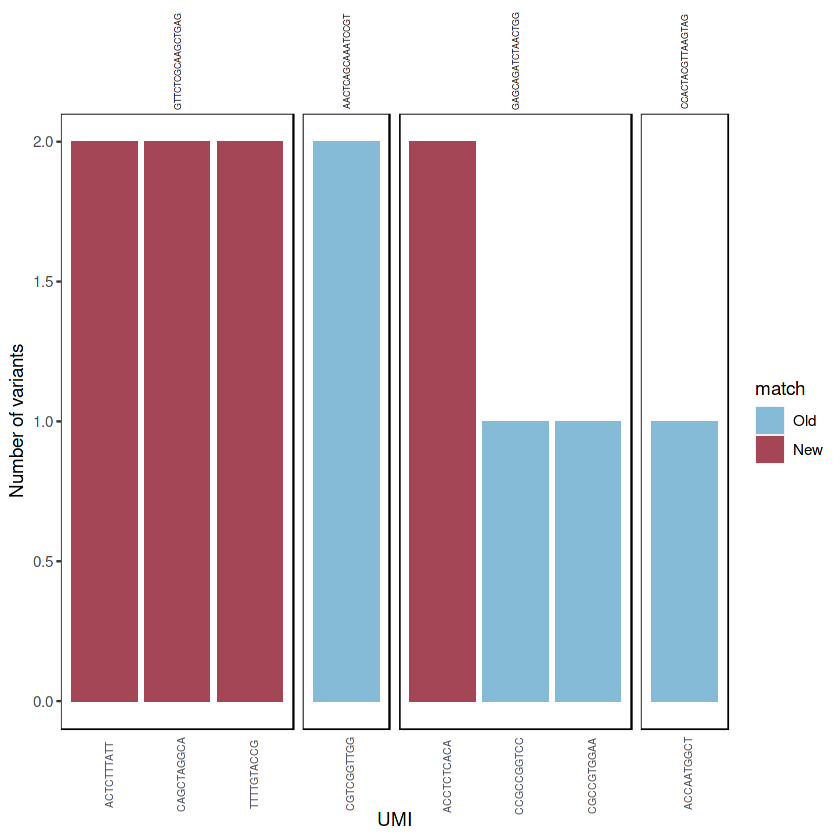

In [71]:
# Stacked barplot with multiple groups
spliced_plot <- unspliced_perc  %>% filter(!position %in% c(130,182,184)) %>% mutate(match = factor(match, levels = c("Old","New"))) %>% mutate(cell = factor(cell, levels = cell_order)) %>%
 ggplot(aes(x=umi, y=n, fill=match)) +
  geom_bar(stat="identity") +
  theme(
       axis.text.x=element_text(angle = 90,size=6),
        axis.ticks.x=element_blank(),
         panel.background = element_blank(), panel.border = element_rect(colour = "black", fill = NA, size = 0.5),
         strip.text.x =element_text(angle=90, size=5),
         strip.background = element_blank()) +
    labs( x= "UMI", y = "Number of variants") +
   scale_fill_manual(values = my_colours) +
   facet_grid(~cell, scales = "free_x", space="free_x")

spliced_plot

fig_save(spliced_plot, filename ="figs/FL/unspliced_UMIs", formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

### 1 Cell: GTTCTCGCAAGCTGAG

In [72]:
celu <- "GTTCTCGCAAGCTGAG"
df_summary %>% filter(cell == celu)

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K2B_S12500-HC,GTTCTCGCAAGCTGAG,42,T,CC.TC,FR1,C-T,6-10,TRUE
K2B_S12500-HC,GTTCTCGCAAGCTGAG,99,T,AG.TA,CDR1,A-C,5-5,TRUE


In [73]:
unspliced_shm %>% filter(cell == celu, position %in% c(141,198)) #130

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample.x,sample.y,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
GTTCTCGCAAGCTGAG,ACTCTTTATT,141,T,C,CC.TC,24,TRUE,V,38,42,T,CC.TC,FR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,114,85,1,84,0,100.00000,11,,75;75;75;75;75;74;74;74;74;74;74;74;73;73;71;72;72;70;69;68;68;68;67;11;11;11;11;11;11;11;11;11;11;11;11;11;1;13;12;12;12;12;12;12;12;12;11;11;11;10;10;10;9;9;8;8;8;7;8;7;7;7;7;7;7;7;6;7;7;7;7;7;8;8;9;9;9;9;9;9;9;9;9,New
GTTCTCGCAAGCTGAG,CAGCTAGGCA,141,T,C,CC.TC,16,TRUE,V,38,42,T,CC.TC,FR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,65,56,1,55,0,98.79518,8,,47;47;47;47;47;47;47;47;47;45;45;45;45;45;45;46;46;47;46;46;46;45;45;44;44;9;9;9;9;9;8;8;8;8;7;7;0;7;7;8;8;9;9;9;9;9;8;8;8;8;8;7;7;7;7;7;7;9;9;9;9;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8,New
GTTCTCGCAAGCTGAG,TTTTGTACCG,141,T,C,CC.TC,13,TRUE,V,38,42,T,CC.TC,FR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,69,54,1,53,0,98.79518,7,,45;45;45;45;45;45;45;45;45;45;45;45;44;44;44;44;44;44;44;44;44;43;43;41;41;3;3;3;3;3;3;3;3;3;1;1;0;3;3;3;3;3;3;3;3;3;4;4;4;4;4;4;4;4;6;7;7;6;6;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8,New
GTTCTCGCAAGCTGAG,ACTCTTTATT,198,A,C,TC.AA,18,TRUE,V,95,99,T,AG.TA,CDR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,114,85,1,84,0,100.00000,11,,75;75;75;75;75;74;74;74;74;74;74;74;73;73;71;72;72;70;69;68;68;68;67;11;11;11;11;11;11;11;11;11;11;11;11;11;1;13;12;12;12;12;12;12;12;12;11;11;11;10;10;10;9;9;8;8;8;7;8;7;7;7;7;7;7;7;6;7;7;7;7;7;8;8;9;9;9;9;9;9;9;9;9,New
GTTCTCGCAAGCTGAG,CAGCTAGGCA,198,A,C,TC.AA,6,TRUE,V,95,99,T,AG.TA,CDR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,65,56,1,55,0,98.79518,8,,47;47;47;47;47;47;47;47;47;45;45;45;45;45;45;46;46;47;46;46;46;45;45;44;44;9;9;9;9;9;8;8;8;8;7;7;0;7;7;8;8;9;9;9;9;9;8;8;8;8;8;7;7;7;7;7;7;9;9;9;9;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8;8,New
GTTCTCGCAAGCTGAG,TTTTGTACCG,198,A,C,TC.AA,11,TRUE,V,95,99,T,AG.TA,CDR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,69,54,1,53,0,98.79518,7,,45;45;45;45;45;45;45;45;45;45;45;45;44;44;44;44;44;44;44;44;44;43;43;41;41;3;3;3;3;3;3;3;3;3;1;1;0;3;3;3;3;3;3;3;3;3;4;4;4;4;4;4;4;4;6;7;7;6;6;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8,New


In [74]:
#raw data umis count
df_intron_ov %>% filter(cell == celu) %>% group_by(position,nucl) %>% count()

position,nucl,n
<int>,<chr>,<int>
130,C,6
130,G,10
141,C,6
141,T,10
198,A,5
198,C,5


### 2 Cell: GTTCTCGCAAGCTGAG

In [75]:
celu <- "AACTCAGCAAATCCGT"
df_summary %>% filter(cell == celu)

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K2B_S13530-HC,AACTCAGCAAATCCGT,1,G,.AG,FR1,A-G,9-13,TRUE
K2B_S13530-HC,AACTCAGCAAATCCGT,13,G,TG.TG,FR1,A-G,10-9,TRUE


In [76]:
unspliced_shm %>% filter(cell == celu)#, position %in% c(141,198))

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample.x,sample.y,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
AACTCAGCAAATCCGT,CGTCGGTTGG,133,G,G,GT.AA,23,TRUE,V,1,1,G,.AG,FR1,K2B_S13530-HC,K2B_S13530,K2B_S13530,HC,94,75,2,74,0,100,60,short(97--103),68;68;68;68;68;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;66;66;65;65;65;65;65;65;65;65;65;65;65;65;65;65;63;63;62;62;61;61;61;61;61;61;61;61;61;61;60;60;60;60;60;60;60;60;60;60;60;60;59;59;59;58;59;59;57;2;2;2;2;2;3;4;5;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;6;6;6;6;6;6,Old
AACTCAGCAAATCCGT,CGTCGGTTGG,145,A,A,TG.TG,23,TRUE,V,13,13,G,TG.TG,FR1,K2B_S13530-HC,K2B_S13530,K2B_S13530,HC,94,75,2,74,0,100,60,short(97--103),68;68;68;68;68;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;67;66;66;65;65;65;65;65;65;65;65;65;65;65;65;65;65;63;63;62;62;61;61;61;61;61;61;61;61;61;61;60;60;60;60;60;60;60;60;60;60;60;60;59;59;59;58;59;59;57;2;2;2;2;2;3;4;5;6;6;6;6;6;6;6;5;5;5;5;5;5;5;5;5;5;5;5;6;6;6;6;6;6,Old


In [77]:
#raw data umis count
raw_shm %>% filter(cell == celu, position %in% c(133,145)) %>% group_by(position,nucl) %>% count()

position,nucl,n
<int>,<chr>,<int>
133,A,15
133,G,23
145,A,23
145,G,15


### 3 Cell: GAGCAGATCTAACTGG

In [78]:
df_summary %>% filter(cell == "GAGCAGATCTAACTGG")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K2B_S12500-HC,GAGCAGATCTAACTGG,15,G,CA.GA,FR1,A-G,24-13,TRUE
K2B_S12500-HC,GAGCAGATCTAACTGG,70,G,CT.TC,FR1,A-G,16-10,TRUE
K2B_S12500-LC,GAGCAGATCTAACTGG,18,G,CA.CC,FR1,A-G,9-6,TRUE


In [79]:
unspliced_shm %>% filter(cell == "GAGCAGATCTAACTGG", position %in% c(110,114,165))

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample.x,sample.y,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
GAGCAGATCTAACTGG,ACCTCTCACA,110,A,G,CA.GA,10,TRUE,V,11,15,G,CA.GA,FR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,11,4,0,4,0,98.79518,3,,2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;0;2;2;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;4;4;4;4;4,New
GAGCAGATCTAACTGG,ACCTCTCACA,165,A,G,CA.TC,10,TRUE,V,66,70,G,CT.TC,FR1,K2B_S12500-HC,K2B_S12500,K2B_S12500,HC,11,4,0,4,0,98.79518,3,,2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;2;0;2;2;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;3;4;4;4;4;4,New
GAGCAGATCTAACTGG,CCGCCGGTCC,114,A,A,CA.CC,13,TRUE,V,18,18,G,CA.CC,FR1,K2B_S12500-LC,K2B_S12500,K2B_S12500,LC,21,13,0,13,0,88.03419,6,,5;5;5;5;5;5;5;5;5;5;5;5;0;0;0;0;0;0;0;0;0;0;0;0;0;0;1;1;2;2;2;2;2;2;2;2;2;2;2;3;3;3;3;3;3;3;3;3;5;5;5;5;5;5;5;6;6;6;6;6;6;6;6;6;6;6;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;8;8;8;8;8,Old
GAGCAGATCTAACTGG,CGCCGTGGAA,114,A,A,CA.CC,9,TRUE,V,18,18,G,CA.CC,FR1,K2B_S12500-LC,K2B_S12500,K2B_S12500,LC,36,30,0,30,0,94.01709,8,,21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;0;0;0;0;0;0;0;2;2;2;2;2;2;2;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;4;5;5;5;5;5;5;7;7;7;7;7;7;7;7;7;7;7;7;7;7;7;8;8;8;8;8;8;8;8;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9;9,Old


In [80]:
raw_shm %>% filter(cell == "GAGCAGATCTAACTGG", position %in% c(110,114,165)) %>% group_by(position,nucl) %>% count()

position,nucl,n
<int>,<chr>,<int>
110,A,39
110,G,22
114,A,29
114,G,20
165,A,39
165,G,22


### 4 Cell: CCACTACGTTAAGTAG

In [81]:
df_summary %>% filter(cell == "CCACTACGTTAAGTAG")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>
K2B_S12118-HC,CCACTACGTTAAGTAG,87,C,TT.AG,CDR1,C-T,5-6,TRUE


In [82]:
unspliced_shm %>% filter(cell == "CCACTACGTTAAGTAG")

cell,umi,position,cons_nucl,nucl,context,depth,productive,region,vgene_position,vgene_position_aligned,nucl_po,context_po,subregion,subject,sample.x,sample.y,chain,total_reads,target_region_reads,spliced_reads,intronic_reads,unsure_reads,intron_coverage_percentage,intron_mediandepth,intron_comments,intron_depths,match
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<chr>
CCACTACGTTAAGTAG,ACCAATGGCT,205,T,T,TT.AG,8,TRUE,V,87,87,C,TT.AG,CDR1,K2B_S12118-HC,K2B_S12118,K2B_S12118,HC,60,49,0,49,0,100,15,,42;42;42;42;42;41;41;41;41;41;41;41;42;42;42;42;42;42;41;41;41;41;41;12;12;12;12;12;12;12;12;12;12;13;13;13;13;13;13;13;13;12;12;13;13;13;13;13;13;13;13;13;13;14;14;15;15;15;16;16;16;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;15;14,Old


In [83]:
raw_shm %>% filter(cell == "CCACTACGTTAAGTAG", position %in% c(205)) %>% group_by(position,nucl) %>% count()

position,nucl,n
<int>,<chr>,<int>
205,C,9
205,T,16
